In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
#from random import sample
import warnings
import time

#sns.set(color_codes=True)

from lifelines.plotting import plot_lifetimes      # Lifeline package for the Survival Analysis
%pylab inline
from lifelines import KaplanMeierFitter
kmf = KaplanMeierFitter()

warnings.filterwarnings('ignore')
%matplotlib inline

Populating the interactive namespace from numpy and matplotlib


In [4]:
t = datetime.datetime.strptime("2020-W01-7", "%G-W%V-%u")
print(t)
t = datetime.datetime.strptime("2020-W01-7", "%G-W%V-%u")
print(t)

2020-01-05 00:00:00
2020-01-05 00:00:00


In [5]:
%run ./CVGI_MR_00_functions.ipynb

Populating the interactive namespace from numpy and matplotlib


In [6]:
imports()

What is the source of the MOVEMENT data? (1=internet, 2=home Mac, 3=office Windows) 3
What type of import is it? (1 = initial (only cases and movement), 2 = initial (full), 3 = data by week, 4 = merged datasets, 5 = only cases) 5



IN
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1185852 entries, 0 to 1185851
Data columns (total 8 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   date             1185852 non-null  object 
 1   GADM_GID_2       1185852 non-null  object 
 2   mun_name         1185852 non-null  object 
 3   movement_change  1185852 non-null  float64
 4   stay_put         1185852 non-null  float64
 5   epi_week         1185852 non-null  object 
 6   ibge_code        1185852 non-null  int64  
 7   pop_2020         1185852 non-null  int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 72.4+ MB

+++++++++++++++++Movement Range, by epidemiological week+++++++++++++++++
 None
<class 'pandas.core.frame.DataFrame'>
Int64Index: 308035 entries, 0 to 308034
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   ibge_code       308035 non-null  objec

---

In [7]:
cases

,ibge_code,epi_week,acc_cases,acc_deaths,new_cases,new_deaths,pop_2019,epi_week_col,acc_cases_100k,acc_deaths_1mi,epi_week_date
0,1100015,2020.18,1,0,1,0,22945.0,2020.18,4.36,0.00,2020-05-10
1,1100015,2020.19,8,0,0,0,22945.0,2020.19,34.87,0.00,2020-05-17
2,1100015,2020.20,7,0,0,0,22945.0,2020.20,30.51,0.00,2020-05-24
3,1100015,2020.21,13,0,3,0,22945.0,2020.21,56.66,0.00,2020-05-31
4,1100015,2020.22,21,0,-1,0,22945.0,2020.22,91.52,0.00,2020-06-07
...,...,...,...,...,...,...,...,...,...,...,...
308030,5300108,2021.17,2316597,49512,6624,263,3015268.0,2021.17,76828.89,16420.43,2021-05-02
308031,5300108,2021.18,2358003,51165,5390,237,3015268.0,2021.18,78202.10,16968.64,2021-05-09
308032,5300108,2021.19,2396055,52654,5311,185,3015268.0,2021.19,79464.08,17462.46,2021-05-16
308033,5300108,2021.20,2433365,53799,5337,142,3015268.0,2021.20,80701.45,17842.20,2021-05-23


In [6]:
events_rs = events_uf('43')
events_rs

event  week
4300034 0     1.0  38.0
        1     1.0  38.0
        2     1.0  39.0
        3     1.0  40.0
4300059 0     1.0  17.0
...           ...   ...
4323804 35    1.0  52.0
        36    1.0  52.0
        37    1.0  54.0
        38    1.0  55.0
        39    1.0  56.0

[27640 rows x 2 columns]

getting the dataframes and plotting for SP, RJ and POA

In [ ]:
#RJ ibge_code == '3304557'
#SP ibge_code == '3550308'
#PA ibge_code == '4314902'

In [7]:
#preparing dataset for PA
city = '4314902'
cases_pa = cases[cases.ibge_code == city]
events_pa = events_cities(cases_pa)
events_pa

,event,week
0,1.0,2.0
1,1.0,2.0
2,1.0,3.0
3,1.0,3.0
4,1.0,4.0
...,...,...
4703,1.0,63.0
4704,1.0,63.0
4705,1.0,63.0
4706,1.0,63.0


In [44]:
#Checking if all deaths are accounted for
city = '4314902'
cases[cases.ibge_code == city].new_deaths.sum()

4708

In [28]:
#preparing dataset for RJ
city = '3304557'
cases_rj = cases[cases.ibge_code == city]
events_rj = events_cities(cases_rj)
events_rj

,event,week
0,1.0,3.0
1,1.0,3.0
2,1.0,3.0
3,1.0,3.0
4,1.0,3.0
...,...,...
25928,1.0,64.0
25929,1.0,64.0
25930,1.0,64.0
25931,1.0,64.0


In [29]:
#Checking if all deaths are accounted for
cases[cases.ibge_code == city].new_deaths.sum()

25933

In [30]:
#preparing dataset for SP
city = '3550308'
cases_sp = cases[cases.ibge_code == city]
events_sp = events_cities(cases_sp)
events_sp

,event,week
0,1.0,3.0
1,1.0,3.0
2,1.0,3.0
3,1.0,3.0
4,1.0,3.0
...,...,...
29875,1.0,65.0
29876,1.0,65.0
29877,1.0,65.0
29878,1.0,65.0


In [31]:
#Checking if all deaths are accounted for
cases[cases.ibge_code == city].new_deaths.sum()

29880

In [35]:
dict_events_cities = {}
dict_events_cities['4314902'] = events_cities(cases_pa)
dict_events_cities['3304557'] = events_cities(cases_rj)
dict_events_cities['3550308'] = events_cities(cases_sp)

{'4314902':       event  week
 0       1.0   2.0
 1       1.0   2.0
 2       1.0   3.0
 3       1.0   3.0
 4       1.0   4.0
 ...     ...   ...
 4703    1.0  63.0
 4704    1.0  63.0
 4705    1.0  63.0
 4706    1.0  63.0
 4707    1.0  63.0
 
 [4708 rows x 2 columns],
 '3304557':        event  week
 0        1.0   3.0
 1        1.0   3.0
 2        1.0   3.0
 3        1.0   3.0
 4        1.0   3.0
 ...      ...   ...
 25928    1.0  64.0
 25929    1.0  64.0
 25930    1.0  64.0
 25931    1.0  64.0
 25932    1.0  64.0
 
 [25933 rows x 2 columns],
 '3550308':        event  week
 0        1.0   3.0
 1        1.0   3.0
 2        1.0   3.0
 3        1.0   3.0
 4        1.0   3.0
 ...      ...   ...
 29875    1.0  65.0
 29876    1.0  65.0
 29877    1.0  65.0
 29878    1.0  65.0
 29879    1.0  65.0
 
 [29880 rows x 2 columns]}

In [37]:
df_events_cities = pd.concat(dict_events_cities)
df_events_cities

event  week
4314902 0        1.0   2.0
        1        1.0   2.0
        2        1.0   3.0
        3        1.0   3.0
        4        1.0   4.0
...              ...   ...
3550308 29875    1.0  65.0
        29876    1.0  65.0
        29877    1.0  65.0
        29878    1.0  65.0
        29879    1.0  65.0

[60521 rows x 2 columns]

In [8]:
%run ./CVGI_MR_00_functions.ipynb

Populating the interactive namespace from numpy and matplotlib


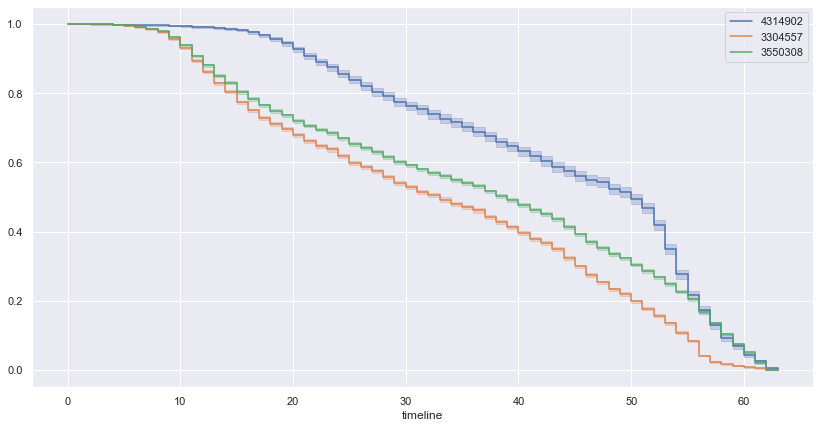

In [50]:
#RJ ibge_code == '3304557'
#SP ibge_code == '3550308'
#PA ibge_code == '4314902'
cities_list = ['4314902', '3304557','3550308'] 
kmf = plot_kmf(df_events_cities,cities_list)

In [54]:
kmf.median_survival_time_

39.0

---

<h4>Scenario A1: Social Vulnerability Index</h4>
1. Select cities with lowest/highest SVI for each region region [list]<br>
2. Prepare the dataframe of events for each city <br>
3. Create a dict of highest SVI cities and of lowest SVI cities<br>
4. Concatenate dict into 2 dataframes: events_svi_high and events_svi_low<br>
5. Fit cases to Kaplan-Meier<br>

Select cities based on SVI:
i. 0% (min) - Luzerna/SC, 4210035 <br>
ii. 25%* - Patrocínio/MG, 3148103 <br>
iii. 50%* - Boa Esperança do Sul/SP, 3506706 <br>
iv. 75%* - Pentecoste/CE, 2310704 <br>
100% (max) - Fernando Falcão/MA, 2104081


In [8]:
#generating the dataframe for the selected cases
cities_list_svi_A1 = ['4210035', '3148103','3506706','2310704','2104081']
events_svi_A1 = events_mc(cities_list_svi_A1)
events_svi_A1

event  week
4210035 0     1.0  15.0
        1     1.0  37.0
        2     1.0  38.0
        3     1.0  44.0
        4     1.0  45.0
...           ...   ...
2310704 70    1.0  53.0
        71    1.0  54.0
        72    1.0  54.0
        73    1.0  54.0
2104081 0     1.0  29.0

[283 rows x 2 columns]

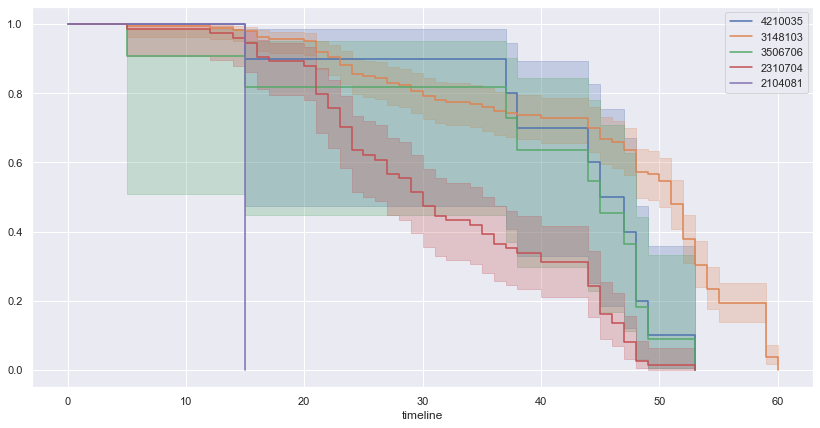

In [40]:
kmf_svi_A1 = plot_kmf(events_svi_A1,cities_list_svi_A1)

In [41]:
kmf_svi_A1.survival_function_


,2104081
timeline,
0.0,1.0
15.0,0.0


In [42]:
kmf_svi_A1.cumulative_density_

,2104081
timeline,
0.0,0.0
15.0,1.0


<h4>Scenario A2: SVI, cities above 20k inhabitants</h4>
i. 0% (min) -  Timbó/SC, 4218202, 44,977 <br>
ii. 25%* -  Patrocínio/MG, 3148103,  91,449  <br>
iii. 50%* -  Feira de Santana/BA, 2910800, 619,609  <br>
iv. 75%* -  Pentecoste/CE, 2310704,  37,900 <br>
100% (max) -  Humberto de Campos/MA, 2105005, 28,932 

In [32]:
#generating the dataframe for the selected cases
cities_list_svi_A2 = ['4218202', '3148103','2910800','2310704','2105005']
events_svi_A2 = events_mc(cities_list_svi_A2)
events_svi_A2

event  week
4218202 0    1.0  14.0
        1    1.0  14.0
        2    1.0  16.0
        3    1.0  16.0
        4    1.0  17.0
...          ...   ...
2105005 5    1.0  22.0
        6    1.0  32.0
        7    1.0  45.0
        8    1.0  48.0
        9    1.0  53.0

[1128 rows x 2 columns]

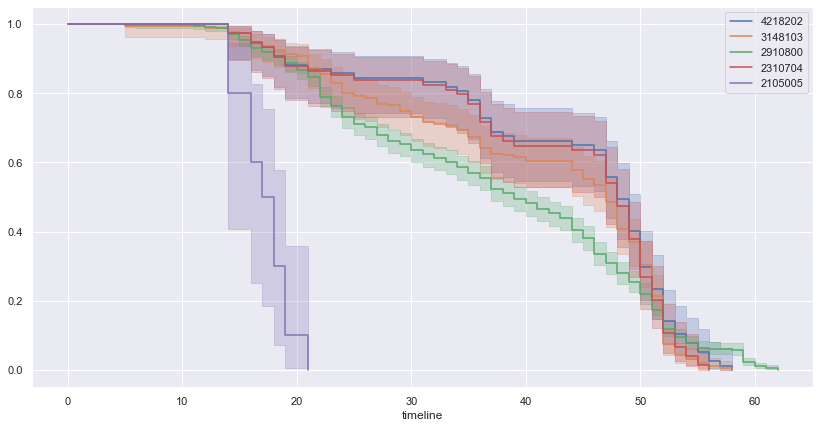

In [33]:
kmf_svi_A2 = plot_kmf(events_svi_A2,cities_list_svi_A2)

<h4>Scenario A3: SVI, cities above 50k inhabitants</h4>
i. 0% (min) -  Tubarão/SC, 4218707, 106,422  <br>
ii. 25%* -  Patrocínio/MG, 3148103,  91,449  <br>
iii. 50%* -  Feira de Santana/BA, 2910800, 619,609  <br>
iv. 75%* - São José de Ribamar/MA, 2111201, 179,028 <br>
100% (max) - Viseu/PA,1508308, 61,751   

In [34]:
#generating the dataframe for the selected cases
cities_list_svi_A3 = ['4218707', '3148103','2910800','2111201','1508308']
events_svi_A3 = events_mc(cities_list_svi_A3)
events_svi_A3

event  week
4218707 0     1.0   3.0
        1     1.0   4.0
        2     1.0   6.0
        3     1.0  12.0
        4     1.0  16.0
...           ...   ...
1508308 27    1.0  54.0
        28    1.0  54.0
        29    1.0  55.0
        30    1.0  55.0
        31    1.0  56.0

[1636 rows x 2 columns]

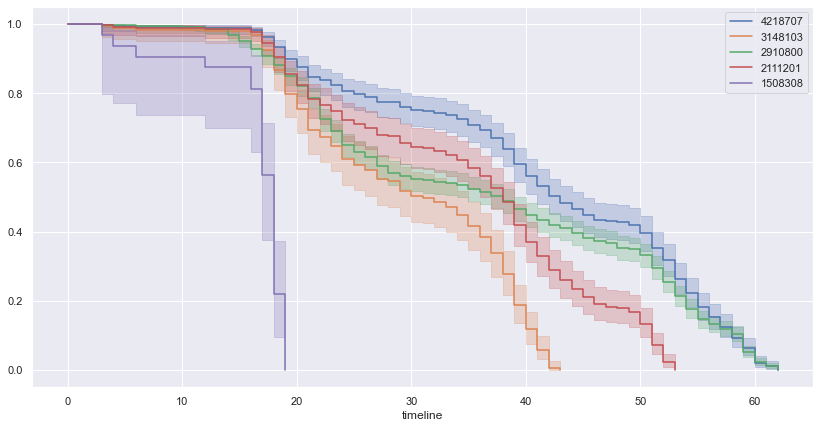

In [37]:
kmf_svi_A3 = plot_kmf(events_svi_A3,cities_list_svi_A3)

<h4>Scenario A4: SVI, cities above 100k inhabitants</h4>
i. 0% (min) -  Tubarão/SC, 4218707, 106,422  <br>
ii. 25%* -  Parnamirim/RN, 2403251, 267,036 <br>
iii. 50%* -  Feira de Santana/BA, 2910800, 619,609  <br>
iv. 75%* - São José de Ribamar/MA, 2111201, 179,028 <br>
100% (max) -  Breves/PA, 1501808, 103,497

In [36]:
#generating the dataframe for the selected cases
cities_list_svi_A4 = ['4218707', '2403251','2910800','2111201','1501808']
events_svi_A4 = events_mc(cities_list_svi_A4)
events_svi_A4

event  week
4218707 0      1.0   3.0
        1      1.0   4.0
        2      1.0   6.0
        3      1.0  12.0
        4      1.0  16.0
...            ...   ...
1501808 106    1.0  52.0
        107    1.0  53.0
        108    1.0  54.0
        109    1.0  54.0
        110    1.0  57.0

[1950 rows x 2 columns]

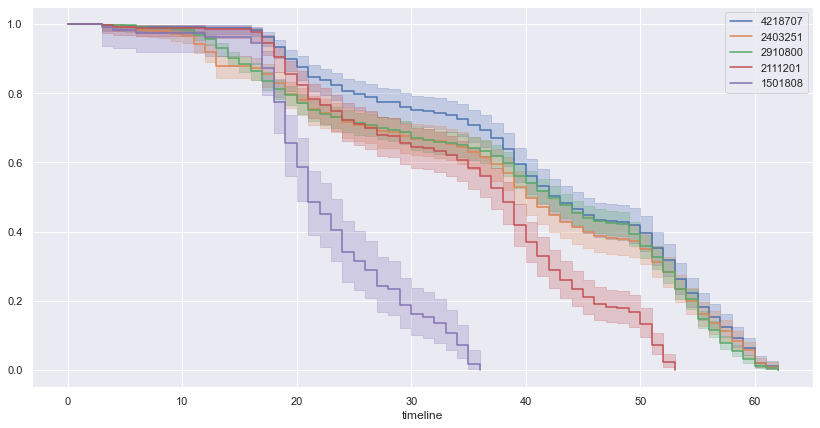

In [38]:
kmf_svi_A4 = plot_kmf(events_svi_A4,cities_list_svi_A4)

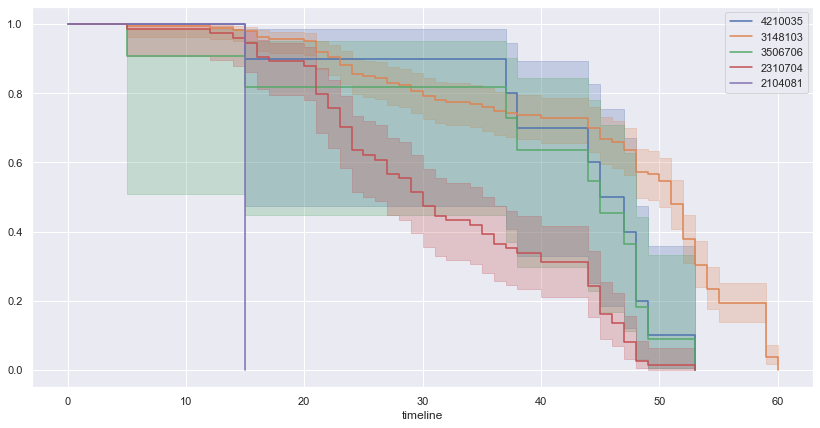

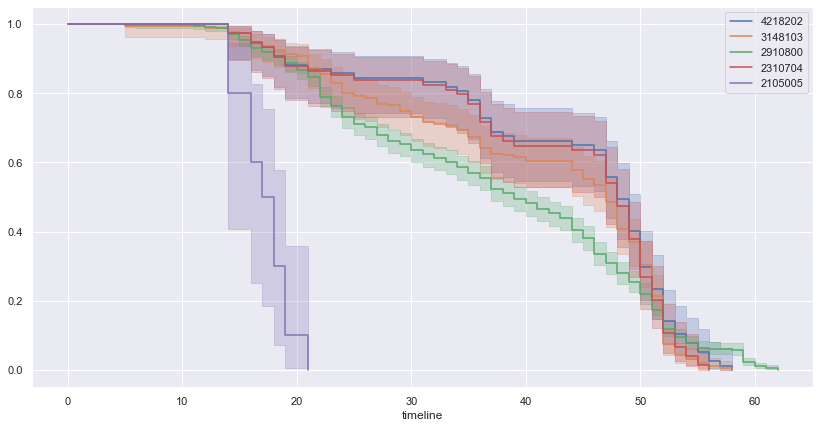

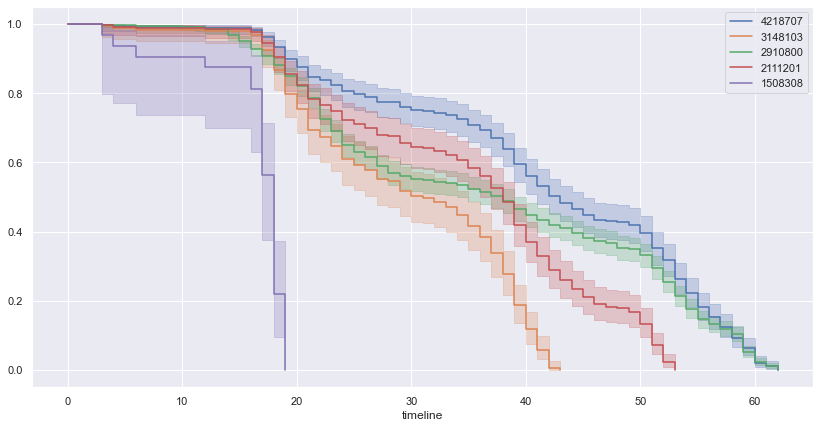

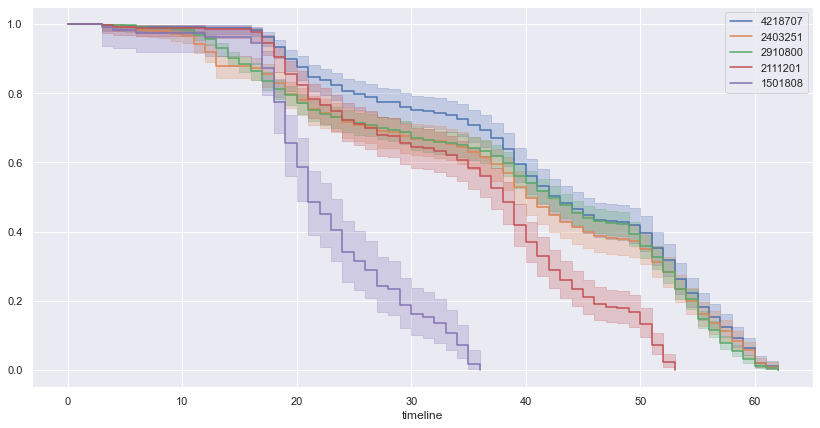

In [63]:
#fig, axes = plt.subplots(2, 2, figsize=(13.5, 7.5))
axes[0][0] = plot_kmf(events_svi_A1,cities_list_svi_A1)
axes[0][1] = plot_kmf(events_svi_A2,cities_list_svi_A2)
axes[1][0] = plot_kmf(events_svi_A3,cities_list_svi_A3)
axes[1][1] = plot_kmf(events_svi_A4,cities_list_svi_A4)

Reordering the cities: from low to high vulnerability

In [8]:
#listing the cities
cities_list_svi_A5 = ['1501808','2111201','2910800','2403251','4218707']
#creating a dict between city names and ibge_code
cities_names_svi_A5_dict = {'1501808':'Breves/PA','2111201':'São José de Ribamar/MA','2910800':'Feira de Santana/BA','2403251':'Parnamirim/RN','4218707':'Tubarão/SC'}
events_svi_A5 = events_mc(cities_list_svi_A5)
events_svi_A5

event  week
1501808 0      1.0   0.0
        1      1.0   1.0
        2      1.0   1.0
        3      1.0   1.0
        4      1.0   1.0
...            ...   ...
4218707 370    1.0  61.0
        371    1.0  62.0
        372    1.0  62.0
        373    1.0  62.0
        374    1.0  62.0

[1950 rows x 2 columns]

In [9]:
events_svi_A5.to_csv('events_svi_A5.csv',encoding='utf-8')

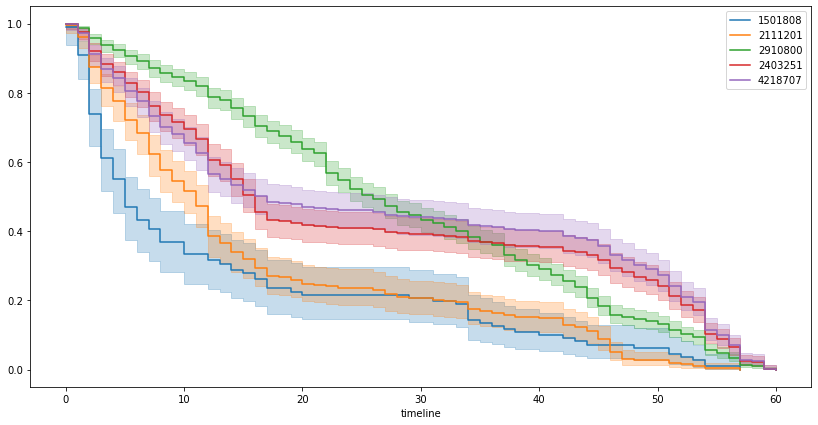

In [10]:
kmf_svi_A5 = plot_kmf(events_svi_A5,cities_list_svi_A5)

In [11]:
#comparing weeks to get the range that is common to all cases
print("Tubarão", events_svi_A5.loc['4218707'].week.min(),events_svi_A5.loc['4218707'].week.max())
print("Parnamirim", events_svi_A5.loc['2403251'].week.min(),events_svi_A5.loc['2403251'].week.max())
print("Feira de Santana",events_svi_A5.loc['2910800'].week.min(),events_svi_A5.loc['2910800'].week.max())
print("São José de Ribamar", events_svi_A5.loc['2111201'].week.min(),events_svi_A5.loc['2111201'].week.max())
print("Breves",events_svi_A5.loc['1501808'].week.min(),events_svi_A5.loc['1501808'].week.max())

Tubarão 3.0 62.0
Parnamirim 5.0 60.0
Feira de Santana 6.0 64.0
São José de Ribamar 2.0 60.0
Breves 0.0 57.0


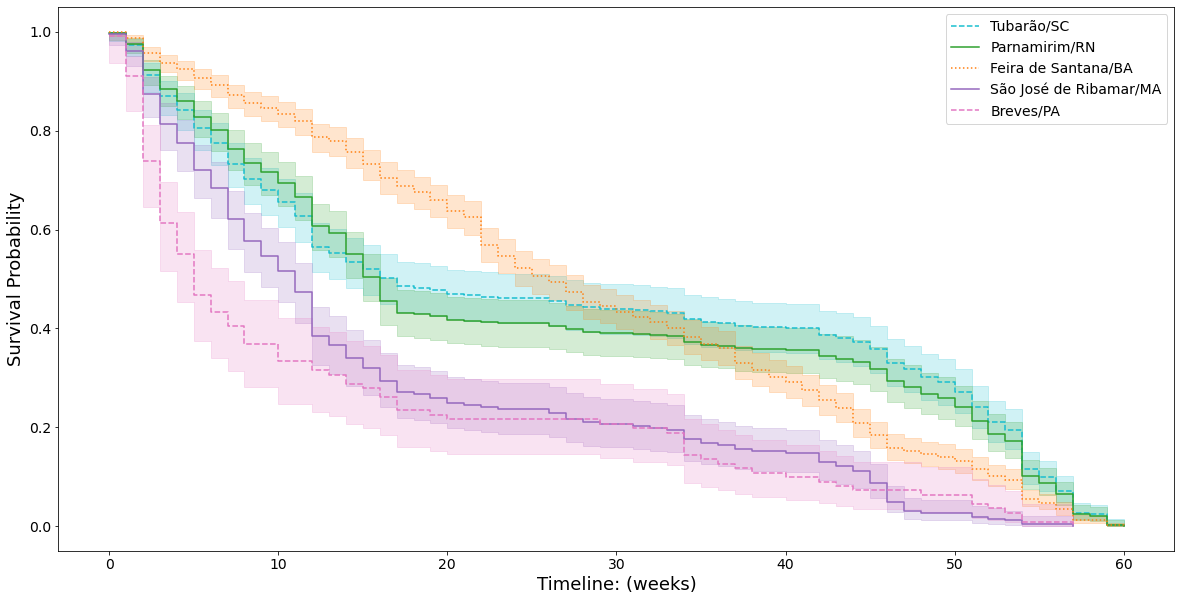

In [12]:
kmf = KaplanMeierFitter() 
df = events_svi_A5
cities_list = cities_list_svi_A5
T = df['week']     ## time to event
E = df['event']      ## event occurred or censored

save_fig = True
ci_alpha_value = 0.2
lineStyles = ['--','-','-.',':']
cmap = matplotlib.cm.get_cmap('tab10') #viridis
#setting font sizes
ss = 14
ms = 18
ls = 24
plt.rc('font', size=ss)          # controls default text sizes
plt.rc('axes', titlesize=ls)     # fontsize of the axes title
plt.rc('axes', labelsize=ms)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=ss)    # fontsize of the tick labels
plt.rc('ytick', labelsize=ss)    # fontsize of the tick labels
plt.rc('legend', fontsize=ss)    # legend fontsize
#plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

fig,ax = plt.subplots(figsize=(20,10))#,gridspec_kw=dict(right=0.9)
ax.grid(True, which='minor',color='grey', linestyle='-', linewidth=2)

cities_label1 = '4218707'
ix1 = df.loc[cities_label1].index
kmf.fit(T[ix1], E[ix1], label=cities_names_svi_A5_dict[cities_label1]) 
ax = kmf.plot(ci_legend=True,ci_alpha=ci_alpha_value, color=cmap(0.95),ls=lineStyles[0])

cities_label2 = '2403251'
ix2 = df.loc[cities_label2].index
kmf.fit(T[ix2], E[ix2], label=cities_names_svi_A5_dict[cities_label2]) 
ax2 = kmf.plot(ax=ax,ci_legend=True,ci_alpha=ci_alpha_value, color=cmap(0.25),ls=lineStyles[1])

cities_label3 = '2910800'
ix3 = df.loc[cities_label3].index
kmf.fit(T[ix3], E[ix3], label=cities_names_svi_A5_dict[cities_label3]) 
ax3 = kmf.plot(ax=ax,ci_legend=True,ci_alpha=ci_alpha_value, color=cmap(0.15),ls=lineStyles[3])

cities_label4 = '2111201'
ix4 = df.loc[cities_label4].index
kmf.fit(T[ix4], E[ix4], label=cities_names_svi_A5_dict[cities_label4]) 
ax4 = kmf.plot(ax=ax,ci_legend=True,ci_alpha=ci_alpha_value, color=cmap(0.45),ls=lineStyles[1])

cities_label5 = '1501808'
ix5 = df.loc[cities_label5].index
kmf.fit(T[ix5], E[ix5], label=cities_names_svi_A5_dict[cities_label5]) 
ax4 = kmf.plot(ax=ax,ci_legend=True,ci_alpha=ci_alpha_value, color=cmap(0.65),ls=lineStyles[0])

ax.set(xlabel='Timeline: (weeks)', ylabel='Survival Probability')#,title='Survival probability per week in sampled cities in Brazil, according to Social Vulnerability Index'

if save_fig == True:
    file_name = 'CVGI_KME_SVI_cities_sample_A5.png'
    file_path = Path('./OUT/')
    url = file_path / file_name
    plt.savefig(url, dpi=300,bbox_inches='tight',pad_inches=0.05)
plt.show()

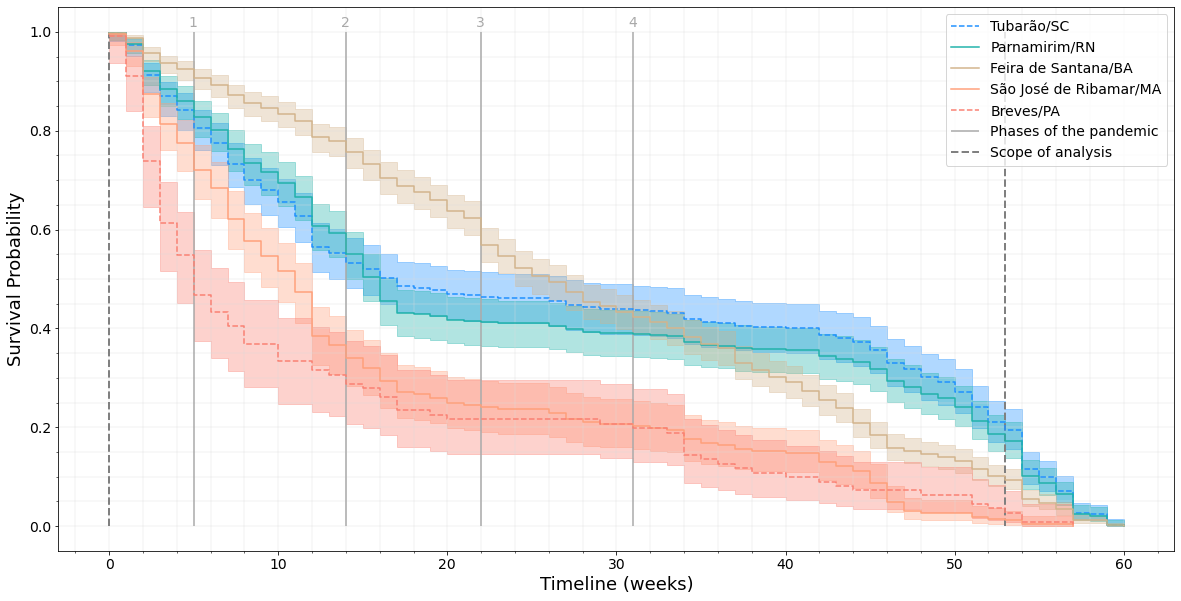

In [14]:
kmf = KaplanMeierFitter() 
df = events_svi_A5
cities_list = cities_list_svi_A5
T = df['week']     ## time to event
E = df['event']      ## event occurred or censored

save_fig = False
ci_alpha_value = 0.35
lineStyles = ['--','-','-.',':']
cmap = matplotlib.cm.get_cmap('tab10') #viridis
color_list = ['dodgerblue','lightseagreen','tan','lightsalmon','salmon']
#setting font sizes
ss = 14
ms = 18
ls = 24
plt.rc('font', size=ss)          # controls default text sizes
plt.rc('axes', titlesize=ls)     # fontsize of the axes title
plt.rc('axes', labelsize=ms)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=ss)    # fontsize of the tick labels
plt.rc('ytick', labelsize=ss)    # fontsize of the tick labels
plt.rc('legend', fontsize=ss)    # legend fontsize
#plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

fig,ax = plt.subplots(figsize=(20,10))#,gridspec_kw=dict(right=0.9)

cities_label1 = '4218707'
ix1 = df.loc[cities_label1].index
kmf.fit(T[ix1], E[ix1], label=cities_names_svi_A5_dict[cities_label1]) 
ax = kmf.plot(ci_legend=True,ci_alpha=ci_alpha_value, color=color_list[0],ls=lineStyles[0])

cities_label2 = '2403251'
ix2 = df.loc[cities_label2].index
kmf.fit(T[ix2], E[ix2], label=cities_names_svi_A5_dict[cities_label2]) 
ax2 = kmf.plot(ax=ax,ci_legend=True,ci_alpha=ci_alpha_value, color=color_list[1],ls=lineStyles[1])

cities_label3 = '2910800'
ix3 = df.loc[cities_label3].index
kmf.fit(T[ix3], E[ix3], label=cities_names_svi_A5_dict[cities_label3]) 
ax3 = kmf.plot(ax=ax,ci_legend=True,ci_alpha=ci_alpha_value, color=color_list[2],ls=lineStyles[1])

cities_label4 = '2111201'
ix4 = df.loc[cities_label4].index
kmf.fit(T[ix4], E[ix4], label=cities_names_svi_A5_dict[cities_label4]) 
ax4 = kmf.plot(ax=ax,ci_legend=True,ci_alpha=ci_alpha_value, color=color_list[3],ls=lineStyles[1])

cities_label5 = '1501808'
ix5 = df.loc[cities_label5].index
kmf.fit(T[ix5], E[ix5], label=cities_names_svi_A5_dict[cities_label5]) 
ax4 = kmf.plot(ax=ax,ci_legend=True,ci_alpha=ci_alpha_value, color=color_list[4],ls=lineStyles[0])

vlines_pos = [5,14,22,31]
ax.vlines(vlines_pos, 0, 1, colors='darkgrey',lw=1.5, linestyles='-', label='Phases of the pandemic')
for i in range(len(vlines_pos)):
    text((vlines_pos[i]-0.3),1.01,i+1,color='darkgrey')
ax.vlines([0,53], 0, 1, colors='grey',lw=2, linestyles='--', label='Scope of analysis')
plt.legend()
plt.minorticks_on()
plt.grid(b=True, which='both',color='gainsboro', linestyle='-', linewidth=0.4)
#plt.grid(b=True, which='minor',color='gainsboro', linestyle='-', linewidth=0.3)
#plt.grid(b=True, which='major',color='grey', linestyle='-', linewidth=0.5)

ax.set(xlabel='Timeline (weeks)', ylabel='Survival Probability')#,title='Survival probability per week in sampled cities in Brazil, according to Social Vulnerability Index'

if save_fig == True:
    file_name = 'CVGI_KME_SVI_cities_sample_A5.png'
    file_path = Path('./OUT/')
    url = file_path / file_name
    plt.savefig(url, dpi=300,bbox_inches='tight',pad_inches=0.05)
plt.show()

---

In [80]:
week_num_df = pd.read_excel("./out/CVGI_SVI_sample_cities_100k.xlsx", sheet_name="epi_week_num", converters={'week_num_py':int64,'epi_week':str})
week_num_df

,week_num_py,epi_week,date_of_ref
0,1,2020.09,2020-02-25
1,2,2020.10,2020-03-03
2,3,2020.11,2020-03-10
3,4,2020.12,2020-03-17
4,5,2020.13,2020-03-24
...,...,...,...
65,66,2021.21,2021-05-25
66,67,2021.22,2021-06-01
67,68,2021.23,2021-06-08
68,69,2021.24,2021-06-15


In [81]:
cases_A5 = cases[cases['ibge_code'].isin(cities_list_svi_A5)]
cases_A5

,ibge_code,epi_week,acc_cases,acc_deaths,new_cases,new_deaths,pop_2019,epi_week_col,acc_cases_100k,acc_deaths_1mi,epi_week_date
10245,1501808,2020.17,37,5,11,1,102701.0,2020.17,36.03,48.69,2020-05-03
10246,1501808,2020.18,216,34,31,9,102701.0,2020.18,210.32,331.06,2020-05-10
10247,1501808,2020.19,827,136,145,19,102701.0,2020.19,805.25,1324.23,2020-05-17
10248,1501808,2020.20,1939,257,163,14,102701.0,2020.20,1888.00,2502.41,2020-05-24
10249,1501808,2020.21,2805,335,82,7,102701.0,2020.21,2731.23,3261.90,2020-05-31
...,...,...,...,...,...,...,...,...,...,...,...
255347,4218707,2021.17,124937,2345,236,12,105686.0,2021.17,118215.28,22188.37,2021-05-02
255348,4218707,2021.18,126721,2424,257,11,105686.0,2021.18,119903.30,22935.87,2021-05-09
255349,4218707,2021.19,128267,2510,174,16,105686.0,2021.19,121366.12,23749.60,2021-05-16
255350,4218707,2021.20,129700,2586,211,4,105686.0,2021.20,122722.03,24468.71,2021-05-23


In [82]:
print(cases_A5.dtypes)
print(week_num_df.dtypes)

ibge_code                 object
epi_week                  object
acc_cases                  int32
acc_deaths                 int32
new_cases                  int32
new_deaths                 int32
pop_2019                 float64
epi_week_col              object
acc_cases_100k           float64
acc_deaths_1mi           float64
epi_week_date     datetime64[ns]
dtype: object
week_num_py             int64
epi_week               object
date_of_ref    datetime64[ns]
dtype: object


In [83]:
cases_A5_merged = cases_A5.merge(right=week_num_df,how="left", on="epi_week") #left_on=True, right_on=False
cases_A5_merged

,ibge_code,epi_week,acc_cases,acc_deaths,new_cases,new_deaths,pop_2019,epi_week_col,acc_cases_100k,acc_deaths_1mi,epi_week_date,week_num_py,date_of_ref
0,1501808,2020.17,37,5,11,1,102701.0,2020.17,36.03,48.69,2020-05-03,9,2020-04-21
1,1501808,2020.18,216,34,31,9,102701.0,2020.18,210.32,331.06,2020-05-10,10,2020-04-28
2,1501808,2020.19,827,136,145,19,102701.0,2020.19,805.25,1324.23,2020-05-17,11,2020-05-05
3,1501808,2020.20,1939,257,163,14,102701.0,2020.20,1888.00,2502.41,2020-05-24,12,2020-05-12
4,1501808,2020.21,2805,335,82,7,102701.0,2020.21,2731.23,3261.90,2020-05-31,13,2020-05-19
...,...,...,...,...,...,...,...,...,...,...,...,...,...
305,4218707,2021.17,124937,2345,236,12,105686.0,2021.17,118215.28,22188.37,2021-05-02,62,2021-04-27
306,4218707,2021.18,126721,2424,257,11,105686.0,2021.18,119903.30,22935.87,2021-05-09,63,2021-05-04
307,4218707,2021.19,128267,2510,174,16,105686.0,2021.19,121366.12,23749.60,2021-05-16,64,2021-05-11
308,4218707,2021.20,129700,2586,211,4,105686.0,2021.20,122722.03,24468.71,2021-05-23,65,2021-05-18


<AxesSubplot:xlabel='week_num_py', ylabel='acc_deaths'>

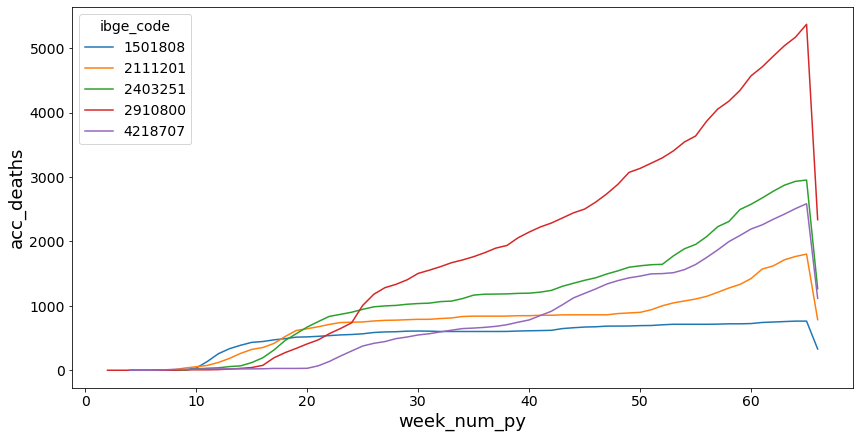

In [87]:
sns.lineplot(x=cases_A5_merged.week_num_py, y=cases_A5_merged.acc_deaths, hue=cases_A5_merged.ibge_code, )

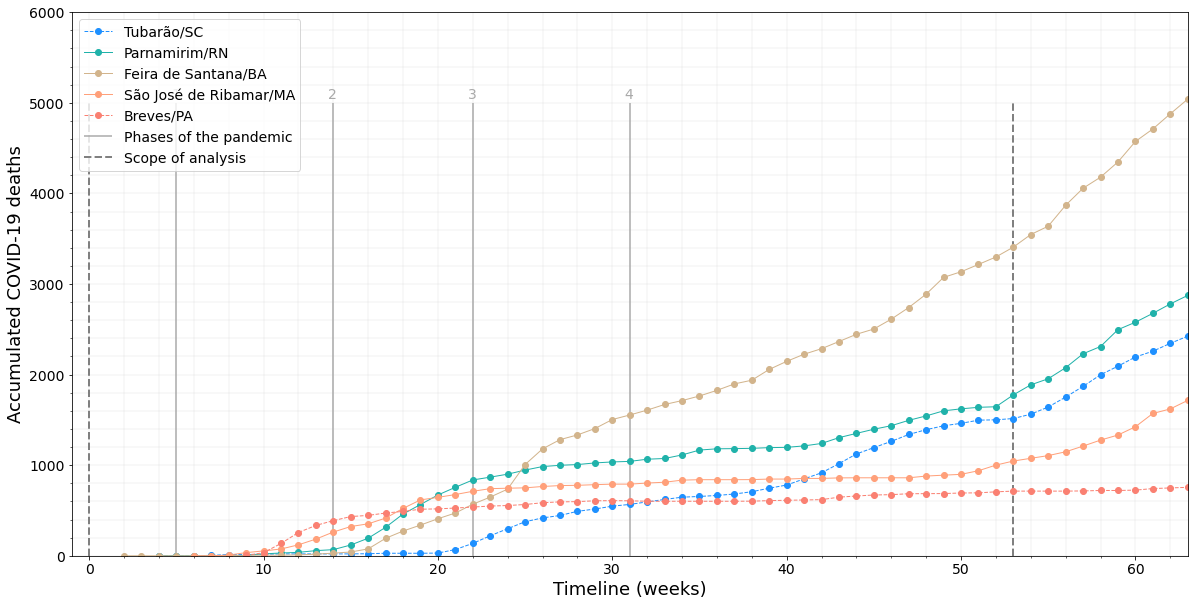

In [112]:
df = cases_A5_merged
cities_list = cities_list_svi_A5
X = 'week_num_py'     ## time to event
Y = 'acc_deaths'      ## event occurred or censored

save_fig = True
ci_alpha_value = 0.35
lineStyles = ['--','-','-.',':']
cmap = matplotlib.cm.get_cmap('tab10') #viridis
color_list = ['dodgerblue','lightseagreen','tan','lightsalmon','salmon']
#setting font sizes
ss = 14
ms = 18
ls = 24
plt.rc('font', size=ss)          # controls default text sizes
plt.rc('axes', titlesize=ls)     # fontsize of the axes title
plt.rc('axes', labelsize=ms)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=ss)    # fontsize of the tick labels
plt.rc('ytick', labelsize=ss)    # fontsize of the tick labels
plt.rc('legend', fontsize=ss)    # legend fontsize
#plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

fig, ax = plt.subplots(figsize=(20,10))

cities_label1 = '4218707'
ax.plot(X, Y, data=df[df.ibge_code==cities_label1], marker='o', markerfacecolor=color_list[0], markersize=6, color=color_list[0], linewidth=1,ls=lineStyles[0],label=cities_names_svi_A5_dict[cities_label1])

cities_label2 = '2403251'
ax.plot(X, Y, data=df[df.ibge_code==cities_label2], marker='o', markerfacecolor=color_list[1], markersize=6, color=color_list[1], linewidth=1,ls=lineStyles[1],label=cities_names_svi_A5_dict[cities_label2])

cities_label3 = '2910800'
ax.plot(X, Y, data=df[df.ibge_code==cities_label3], marker='o', markerfacecolor=color_list[2], markersize=6, color=color_list[2], linewidth=1,ls=lineStyles[1],label=cities_names_svi_A5_dict[cities_label3])

cities_label4 = '2111201'
ax.plot(X, Y, data=df[df.ibge_code==cities_label4], marker='o', markerfacecolor=color_list[3], markersize=6, color=color_list[3], linewidth=1,ls=lineStyles[1],label=cities_names_svi_A5_dict[cities_label4])

cities_label5 = '1501808'
ax.plot(X, Y, data=df[df.ibge_code==cities_label5], marker='o', markerfacecolor=color_list[4], markersize=6, color=color_list[4], linewidth=1,ls=lineStyles[0],label=cities_names_svi_A5_dict[cities_label5])

vlines_pos = [5,14,22,31]
ax.vlines(vlines_pos, 0, 5000, colors='darkgrey',lw=1.5, linestyles='-', label='Phases of the pandemic')
for i in range(len(vlines_pos)):
    text((vlines_pos[i]-0.3),5050,i+1,color='darkgrey')
ax.vlines([0,53], 0, 5000, colors='grey',lw=2, linestyles='--', label='Scope of analysis')
plt.legend()
plt.minorticks_on()
plt.grid(b=True, which='both',color='gainsboro', linestyle='-', linewidth=0.4)
#plt.grid(b=True, which='minor',color='gainsboro', linestyle='-', linewidth=0.3)
#plt.grid(b=True, which='major',color='grey', linestyle='-', linewidth=0.5)

ax.set(xlabel='Timeline (weeks)', ylabel='Accumulated COVID-19 deaths',ylim=[0,6000],xlim=[-1,63])

if save_fig == True:
    file_name = 'CVGI_ACCDeaths_SVI_cities_sample_A5.png'
    file_path = Path('./OUT/')
    url = file_path / file_name
    plt.savefig(url, dpi=300,bbox_inches='tight',pad_inches=0.05)
plt.show()

---

<h4>Scenario A6: 53 weeks</h4>

In [51]:
#listing the cities
cities_list_svi_A6 = ['1501808','2111201','2910800','2403251','4218707']
#creating a dict between city names and ibge_code
cities_names_svi_A6_dict = {'1501808':'Breves/PA','2111201':'São José de Ribamar/MA','2910800':'Feira de Santana/BA','2403251':'Parnamirim/RN','4218707':'Tubarão/SC'}
events_svi_A6 = events_mc(cities_list_svi_A6,'2021-02-25 00:00:00')
events_svi_A6

event  week
1501808 0      1.0   0.0
        1      1.0   1.0
        2      1.0   1.0
        3      1.0   1.0
        4      1.0   1.0
...            ...   ...
4218707 200    1.0  45.0
        201    1.0  45.0
        202    1.0  46.0
        203    1.0  46.0
        204    1.0  47.0

[1136 rows x 2 columns]

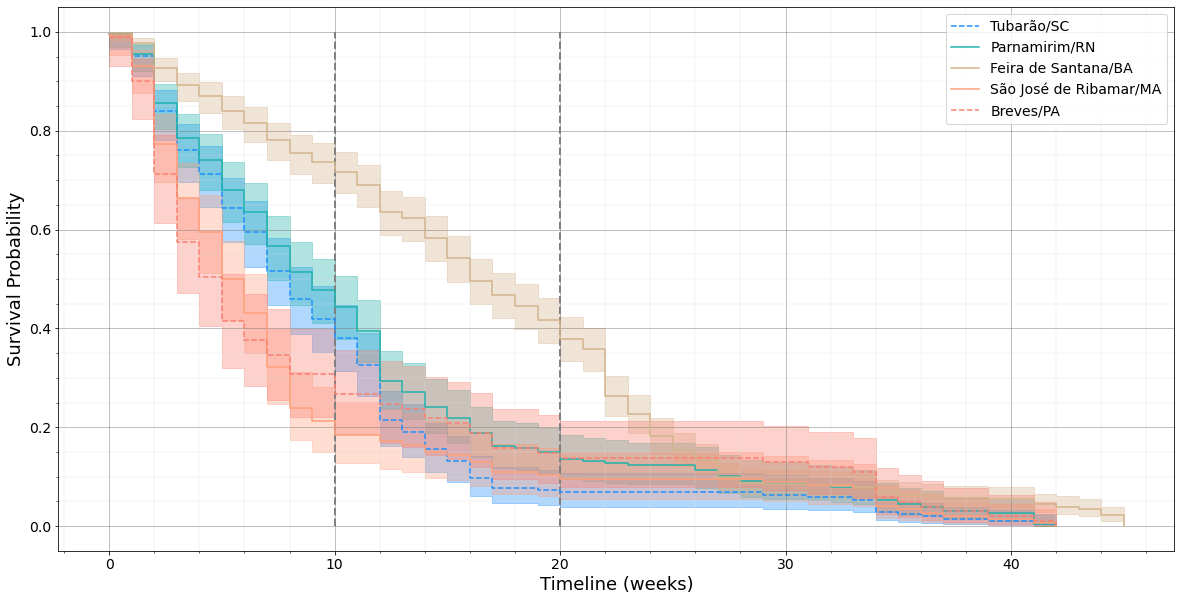

In [119]:
kmf = KaplanMeierFitter() 
df = events_svi_A6
cities_list = cities_list_svi_A6
T = df['week']     ## time to event
E = df['event']      ## event occurred or censored

save_fig = False
ci_alpha_value = 0.35
lineStyles = ['--','-','-.',':']
cmap = matplotlib.cm.get_cmap('tab10') #viridis
color_list = ['dodgerblue','lightseagreen','tan','lightsalmon','salmon']
#setting font sizes
ss = 14
ms = 18
ls = 24
plt.rc('font', size=ss)          # controls default text sizes
plt.rc('axes', titlesize=ls)     # fontsize of the axes title
plt.rc('axes', labelsize=ms)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=ss)    # fontsize of the tick labels
plt.rc('ytick', labelsize=ss)    # fontsize of the tick labels
plt.rc('legend', fontsize=ss)    # legend fontsize
#plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

fig,ax = plt.subplots(figsize=(20,10))#,gridspec_kw=dict(right=0.9)

cities_label1 = '4218707'
ix1 = df.loc[cities_label1].index
kmf.fit(T[ix1], E[ix1], label=cities_names_svi_A5_dict[cities_label1]) 
ax = kmf.plot(ci_legend=True,ci_alpha=ci_alpha_value, color=color_list[0],ls=lineStyles[0])

cities_label2 = '2403251'
ix2 = df.loc[cities_label2].index
kmf.fit(T[ix2], E[ix2], label=cities_names_svi_A5_dict[cities_label2]) 
ax2 = kmf.plot(ax=ax,ci_legend=True,ci_alpha=ci_alpha_value, color=color_list[1],ls=lineStyles[1])

cities_label3 = '2910800'
ix3 = df.loc[cities_label3].index
kmf.fit(T[ix3], E[ix3], label=cities_names_svi_A5_dict[cities_label3]) 
ax3 = kmf.plot(ax=ax,ci_legend=True,ci_alpha=ci_alpha_value, color=color_list[2],ls=lineStyles[1])

cities_label4 = '2111201'
ix4 = df.loc[cities_label4].index
kmf.fit(T[ix4], E[ix4], label=cities_names_svi_A5_dict[cities_label4]) 
ax4 = kmf.plot(ax=ax,ci_legend=True,ci_alpha=ci_alpha_value, color=color_list[3],ls=lineStyles[1])

cities_label5 = '1501808'
ix5 = df.loc[cities_label5].index
kmf.fit(T[ix5], E[ix5], label=cities_names_svi_A5_dict[cities_label5]) 
ax4 = kmf.plot(ax=ax,ci_legend=True,ci_alpha=ci_alpha_value, color=color_list[4],ls=lineStyles[0])
ax.vlines([10,20], 0, 1, colors='grey',lw=2, linestyles='--')
plt.minorticks_on()
plt.grid(b=True, which='minor',color='gainsboro', linestyle='-', linewidth=0.3)
plt.grid(b=True, which='major',color='grey', linestyle='-', linewidth=0.5)


ax.set(xlabel='Timeline (weeks)', ylabel='Survival Probability')#,title='Survival probability per week in sampled cities in Brazil, according to Social Vulnerability Index'

if save_fig == True:
    file_name = 'CVGI_KME_SVI_cities_sample_A5.png'
    file_path = Path('./OUT/')
    url = file_path / file_name
    plt.savefig(url, dpi=300,bbox_inches='tight',pad_inches=0.05)
plt.show()

In [53]:
events_svi_A6['ibge_code'] = events_svi_A6.index.to_numpy() 
for i in range(len(events_svi_A6)):
    events_svi_A6.ibge_code[i] = events_svi_A6.ibge_code[i][0]
events_svi_A6

event  week ibge_code
1501808 0      1.0   0.0   1501808
        1      1.0   1.0   1501808
        2      1.0   1.0   1501808
        3      1.0   1.0   1501808
        4      1.0   1.0   1501808
...            ...   ...       ...
4218707 200    1.0  45.0   4218707
        201    1.0  45.0   4218707
        202    1.0  46.0   4218707
        203    1.0  46.0   4218707
        204    1.0  47.0   4218707

[1136 rows x 3 columns]

In [113]:
events_svi_A6.dtypes

event        float64
week         float64
ibge_code     object
dtype: object

In [79]:
import pandas as pd
from lifelines.statistics import multivariate_logrank_test

df = pd.DataFrame({
    'durations': [5, 3, 9, 8, 7, 4, 4, 3, 2, 5, 6, 7],
    'groups': [0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2], # could be strings too
    'events': [1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0],
})

results = multivariate_logrank_test(df['durations'], df['groups'], df['events'])
results.print_summary()

"""
              t_0 = -1
            alpha = 0.95
null_distribution = chi squared
               df = 2

---
test_statistic      p
        1.0800 0.5827
---
"""

<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 2
         test_name = multivariate_logrank_test

---
 test_statistic    p  -log2(p)
           1.08 0.58      0.78

'\n              t_0 = -1\n            alpha = 0.95\nnull_distribution = chi squared\n               df = 2\n\n---\ntest_statistic      p\n        1.0800 0.5827\n---\n'

Getting data for the pandemic phases

In [67]:
cities_list_svi_A5 = ['1501808','2111201','2910800','2403251','4218707']
cases_A5 = cases[cases['ibge_code'].isin(cities_list_svi_A5)]
cases_A5

,ibge_code,epi_week,acc_cases,acc_deaths,new_cases,new_deaths,pop_2019,epi_week_col,acc_cases_100k,acc_deaths_1mi,epi_week_date
10245,1501808,2020.17,37,5,11,1,102701.0,2020.17,36.03,48.69,2020-05-03
10246,1501808,2020.18,216,34,31,9,102701.0,2020.18,210.32,331.06,2020-05-10
10247,1501808,2020.19,827,136,145,19,102701.0,2020.19,805.25,1324.23,2020-05-17
10248,1501808,2020.20,1939,257,163,14,102701.0,2020.20,1888.00,2502.41,2020-05-24
10249,1501808,2020.21,2805,335,82,7,102701.0,2020.21,2731.23,3261.90,2020-05-31
...,...,...,...,...,...,...,...,...,...,...,...
255347,4218707,2021.17,124937,2345,236,12,105686.0,2021.17,118215.28,22188.37,2021-05-02
255348,4218707,2021.18,126721,2424,257,11,105686.0,2021.18,119903.30,22935.87,2021-05-09
255349,4218707,2021.19,128267,2510,174,16,105686.0,2021.19,121366.12,23749.60,2021-05-16
255350,4218707,2021.20,129700,2586,211,4,105686.0,2021.20,122722.03,24468.71,2021-05-23


In [21]:
cases_A5[cases_A5.epi_week == "2020.13"]

,ibge_code,epi_week,acc_cases,acc_deaths,new_cases,new_deaths,pop_2019,epi_week_col,acc_cases_100k,acc_deaths_1mi,epi_week_date
62755,2403251,2020.13,31,0,7,0,261469.0,2020.13,11.86,0.0,2020-04-05
110284,2910800,2020.13,55,0,3,0,614872.0,2020.13,8.94,0.0,2020-04-05
255290,4218707,2020.13,54,0,2,0,105686.0,2020.13,51.09,0.0,2020-04-05


In [30]:
print("Accumulated cases in epid. week 09.2020",cases[cases.epi_week <= "2020.09"].new_cases.sum())
print("Accumulated cases in epid. week 13.2020",cases[cases.epi_week <= "2020.13"].new_cases.sum())
print("Accumulated cases in epid. week 22.2020",cases[cases.epi_week <= "2020.22"].new_cases.sum())
print("Accumulated cases in epid. week 30.2020",cases[cases.epi_week <= "2020.30"].new_cases.sum())
print("Accumulated cases in epid. week 39.2020",cases[cases.epi_week <= "2020.39"].new_cases.sum())
print("Accumulated cases in epid. week 08.2021",cases[cases.epi_week <= "2021.08"].new_cases.sum())

Accumulated cases in epid. week 09.2020 2
Accumulated cases in epid. week 13.2020 3669
Accumulated cases in epid. week 22.2020 499331
Accumulated cases in epid. week 30.2020 2376484
Accumulated cases in epid. week 39.2020 4618796
Accumulated cases in epid. week 08.2021 10438360


In [31]:
print("Accumulated cases in epid. week 09.2020",cases[cases.epi_week <= "2020.09"].new_deaths.sum())
print("Accumulated cases in epid. week 13.2020",cases[cases.epi_week <= "2020.13"].new_deaths.sum())
print("Accumulated cases in epid. week 22.2020",cases[cases.epi_week <= "2020.22"].new_deaths.sum())
print("Accumulated cases in epid. week 30.2020",cases[cases.epi_week <= "2020.30"].new_deaths.sum())
print("Accumulated cases in epid. week 39.2020",cases[cases.epi_week <= "2020.39"].new_deaths.sum())
print("Accumulated cases in epid. week 08.2021",cases[cases.epi_week <= "2021.08"].new_deaths.sum())

Accumulated cases in epid. week 09.2020 0
Accumulated cases in epid. week 13.2020 97
Accumulated cases in epid. week 22.2020 28848
Accumulated cases in epid. week 30.2020 86252
Accumulated cases in epid. week 39.2020 139703
Accumulated cases in epid. week 08.2021 253372


In [244]:
print("Accumulated cases in epid. week 09.2020 at", cities_names_svi_A5_dict[cities_list_svi_A5[0]],cases_A5[(cases_A5.epi_week <= "2020.09")&(cases_A5.ibge_code ==cities_list_svi_A5[0])].new_deaths.sum())
print("Accumulated cases in epid. week 02.2021 at", cities_names_svi_A5_dict[cities_list_svi_A5[0]],cases_A5[(cases_A5.epi_week <= "2021.08")&(cases_A5.ibge_code ==cities_list_svi_A5[0])].new_deaths.sum())
print("Accumulated cases in epid. week 09.2020 at", cities_names_svi_A5_dict[cities_list_svi_A5[1]],cases_A5[(cases_A5.epi_week <= "2020.09")&(cases_A5.ibge_code ==cities_list_svi_A5[1])].new_deaths.sum())
print("Accumulated cases in epid. week 02.2021 at", cities_names_svi_A5_dict[cities_list_svi_A5[1]],cases_A5[(cases_A5.epi_week <= "2021.08")&(cases_A5.ibge_code ==cities_list_svi_A5[1])].new_deaths.sum())
print("Accumulated cases in epid. week 09.2020 at", cities_names_svi_A5_dict[cities_list_svi_A5[2]],cases_A5[(cases_A5.epi_week <= "2020.09")&(cases_A5.ibge_code ==cities_list_svi_A5[2])].new_deaths.sum())
print("Accumulated cases in epid. week 02.2021 at", cities_names_svi_A5_dict[cities_list_svi_A5[2]],cases_A5[(cases_A5.epi_week <= "2021.08")&(cases_A5.ibge_code ==cities_list_svi_A5[2])].new_deaths.sum())
print("Accumulated cases in epid. week 09.2020 at", cities_names_svi_A5_dict[cities_list_svi_A5[3]],cases_A5[(cases_A5.epi_week <= "2020.09")&(cases_A5.ibge_code ==cities_list_svi_A5[3])].new_deaths.sum())
print("Accumulated cases in epid. week 02.2021 at", cities_names_svi_A5_dict[cities_list_svi_A5[3]],cases_A5[(cases_A5.epi_week <= "2021.08")&(cases_A5.ibge_code ==cities_list_svi_A5[3])].new_deaths.sum())
print("Accumulated cases in epid. week 09.2020 at", cities_names_svi_A5_dict[cities_list_svi_A5[4]],cases_A5[(cases_A5.epi_week <= "2020.09")&(cases_A5.ibge_code ==cities_list_svi_A5[4])].new_deaths.sum())
print("Accumulated cases in epid. week 02.2021 at", cities_names_svi_A5_dict[cities_list_svi_A5[4]],cases_A5[(cases_A5.epi_week <= "2021.08")&(cases_A5.ibge_code ==cities_list_svi_A5[4])].new_deaths.sum())

Accumulated cases in epid. week 09.2020 at Breves/PA 0
Accumulated cases in epid. week 02.2021 at Breves/PA 102
Accumulated cases in epid. week 09.2020 at São José de Ribamar/MA 0
Accumulated cases in epid. week 02.2021 at São José de Ribamar/MA 151
Accumulated cases in epid. week 09.2020 at Feira de Santana/BA 0
Accumulated cases in epid. week 02.2021 at Feira de Santana/BA 498
Accumulated cases in epid. week 09.2020 at Parnamirim/RN 0
Accumulated cases in epid. week 02.2021 at Parnamirim/RN 256
Accumulated cases in epid. week 09.2020 at Tubarão/SC 0
Accumulated cases in epid. week 02.2021 at Tubarão/SC 218


In [245]:
print("Accumulated cases in epid. week 09.2020 at", cities_names_svi_A5_dict[cities_list_svi_A5[0]],cases_A5[(cases_A5.epi_week <= "2020.09")&(cases_A5.ibge_code ==cities_list_svi_A5[0])].new_cases.sum())
print("Accumulated cases in epid. week 02.2021 at", cities_names_svi_A5_dict[cities_list_svi_A5[0]],cases_A5[(cases_A5.epi_week <= "2021.08")&(cases_A5.ibge_code ==cities_list_svi_A5[0])].new_cases.sum())
print("Accumulated cases in epid. week 09.2020 at", cities_names_svi_A5_dict[cities_list_svi_A5[1]],cases_A5[(cases_A5.epi_week <= "2020.09")&(cases_A5.ibge_code ==cities_list_svi_A5[1])].new_cases.sum())
print("Accumulated cases in epid. week 02.2021 at", cities_names_svi_A5_dict[cities_list_svi_A5[1]],cases_A5[(cases_A5.epi_week <= "2021.08")&(cases_A5.ibge_code ==cities_list_svi_A5[1])].new_cases.sum())
print("Accumulated cases in epid. week 09.2020 at", cities_names_svi_A5_dict[cities_list_svi_A5[2]],cases_A5[(cases_A5.epi_week <= "2020.09")&(cases_A5.ibge_code ==cities_list_svi_A5[2])].new_cases.sum())
print("Accumulated cases in epid. week 02.2021 at", cities_names_svi_A5_dict[cities_list_svi_A5[2]],cases_A5[(cases_A5.epi_week <= "2021.08")&(cases_A5.ibge_code ==cities_list_svi_A5[2])].new_cases.sum())
print("Accumulated cases in epid. week 09.2020 at", cities_names_svi_A5_dict[cities_list_svi_A5[3]],cases_A5[(cases_A5.epi_week <= "2020.09")&(cases_A5.ibge_code ==cities_list_svi_A5[3])].new_cases.sum())
print("Accumulated cases in epid. week 02.2021 at", cities_names_svi_A5_dict[cities_list_svi_A5[3]],cases_A5[(cases_A5.epi_week <= "2021.08")&(cases_A5.ibge_code ==cities_list_svi_A5[3])].new_cases.sum())
print("Accumulated cases in epid. week 09.2020 at", cities_names_svi_A5_dict[cities_list_svi_A5[4]],cases_A5[(cases_A5.epi_week <= "2020.09")&(cases_A5.ibge_code ==cities_list_svi_A5[4])].new_cases.sum())
print("Accumulated cases in epid. week 02.2021 at", cities_names_svi_A5_dict[cities_list_svi_A5[4]],cases_A5[(cases_A5.epi_week <= "2021.08")&(cases_A5.ibge_code ==cities_list_svi_A5[4])].new_cases.sum())

Accumulated cases in epid. week 09.2020 at Breves/PA 0
Accumulated cases in epid. week 02.2021 at Breves/PA 3578
Accumulated cases in epid. week 09.2020 at São José de Ribamar/MA 0
Accumulated cases in epid. week 02.2021 at São José de Ribamar/MA 1748
Accumulated cases in epid. week 09.2020 at Feira de Santana/BA 0
Accumulated cases in epid. week 02.2021 at Feira de Santana/BA 29106
Accumulated cases in epid. week 09.2020 at Parnamirim/RN 0
Accumulated cases in epid. week 02.2021 at Parnamirim/RN 16051
Accumulated cases in epid. week 09.2020 at Tubarão/SC 0
Accumulated cases in epid. week 02.2021 at Tubarão/SC 14062


---

Testing for a large number of cities

<h2>For later development/implementation</h2>

<h4>Scenario B: Municipal Human Development Index</h4>
1. Select cities with lowest/highest MHDI for each region region [list]
2. Prepare the dataframe of events for each city
3. Create a dict of highest MHDI cities and of lowest MHDI cities
4. Concatenate dict into 2 dataframes: events_mhdi_high and events_mhdi_low
5. Fit cases to Kaplan-Meier

<h4>Scenario C: COVID Mortality</h4>
1. Select cities with lowest/highest mortality rate per million for each region region [list]
2. Prepare the dataframe of events for each city
3. Create a dict of highest mortality rate cities and of lowest mortality rate cities
4. Concatenate dict into 2 dataframes: events_mort_high and events_mort_low
5. Fit cases to Kaplan-Meier

---

exploratory again

In [ ]:
cities_list = ['4309050', '4314068','4314308','4315305','4313003','4312617'] 
kmf = plot_kmf(events_rs,cities_list)

In [39]:
cases.describe()

,acc_cases,acc_deaths,new_cases,new_deaths,pop_2019,acc_cases_100k,acc_deaths_1mi
count,3.080350e+05,308035.000000,308035.000000,308035.000000,3.080350e+05,308035.000000,308035.000000
mean,8.315155e+03,228.352197,52.007824,1.454666,4.121959e+04,19252.871498,3779.840029
std,5.641156e+04,2325.247722,329.669885,13.413192,2.399519e+05,20540.967376,4262.055788
min,0.000000e+00,0.000000,-2902.000000,-53.000000,7.810000e+02,0.000000,0.000000
25%,3.320000e+02,7.000000,1.000000,0.000000,5.678000e+03,3887.790000,479.215000
50%,1.373000e+03,28.000000,8.000000,0.000000,1.233700e+04,13141.580000,2546.840000
75%,4.496000e+03,91.000000,29.000000,1.000000,2.695200e+04,27776.030000,5585.910000
max,5.310756e+06,206285.000000,42546.000000,1401.000000,1.225202e+07,922404.370000,158860.270000


In [45]:
city = '4314902'
cases_pa = cases[cases.ibge_code == city]

In [48]:
uf = '43'
cases_rs = cases[(cases['ibge_code'].str.startswith(uf))]
cases_rs

,ibge_code,epi_week,acc_cases,acc_deaths,new_cases,new_deaths,pop_2019,epi_week_col,acc_cases_100k,acc_deaths_1mi,epi_week_date
256342,4300034,2020.29,1,0,0,0,4901.0,2020.29,20.40,0.00,2020-07-26
256343,4300034,2020.30,0,0,0,0,4901.0,2020.30,0.00,0.00,2020-08-02
256344,4300034,2020.31,0,0,0,0,4901.0,2020.31,0.00,0.00,2020-08-09
256345,4300034,2020.32,0,0,0,0,4901.0,2020.32,0.00,0.00,2020-08-16
256346,4300034,2020.33,0,0,0,0,4901.0,2020.33,0.00,0.00,2020-08-23
...,...,...,...,...,...,...,...,...,...,...,...
282897,4323804,2021.17,4972,239,47,2,16408.0,2021.17,30302.29,14566.07,2021-05-02
282898,4323804,2021.18,5415,245,99,0,16408.0,2021.18,33002.19,14931.74,2021-05-09
282899,4323804,2021.19,5950,249,29,1,16408.0,2021.19,36262.80,15175.52,2021-05-16
282900,4323804,2021.20,6082,256,4,1,16408.0,2021.20,37067.28,15602.15,2021-05-23


In [49]:
cases_rs.describe()

,acc_cases,acc_deaths,new_cases,new_deaths,pop_2019,acc_cases_100k,acc_deaths_1mi
count,26560.000000,26560.000000,26560.000000,26560.000000,2.656000e+04,26560.000000,26560.000000
mean,5472.635919,124.545708,40.145482,1.040060,2.558551e+04,21198.656223,3923.468125
std,26122.384886,771.615718,172.275357,6.153879,8.752490e+04,23910.385750,5129.155620
min,0.000000,0.000000,-28.000000,-1.000000,1.034000e+03,0.000000,0.000000
25%,182.000000,0.000000,1.000000,0.000000,3.018000e+03,3308.217500,0.000000
50%,740.000000,14.000000,5.000000,0.000000,5.981000e+03,13052.495000,2216.730000
75%,2604.000000,49.000000,22.000000,0.000000,1.829300e+04,31727.202500,5754.210000
max,869519.000000,32443.000000,9061.000000,342.000000,1.483771e+06,922404.370000,158860.270000


In [91]:
var = 'new_deaths'
cases_rs_clip1 = pd.DataFrame(cases_rs[[var,'epi_week_date','ibge_code']],index=cases_rs.index)
cases_rs_clip2 = cases_rs_clip1[cases_rs_clip1['ibge_code'].str.startswith('4314')]
cases_rs_clip2

,new_deaths,epi_week_date,ibge_code
272250,0,2020-04-05,4314001
272251,0,2020-04-12,4314001
272252,0,2020-04-19,4314001
272253,0,2020-04-26,4314001
272254,0,2020-05-03,4314001
...,...,...,...
273731,116,2021-05-02,4314902
273732,122,2021-05-09,4314902
273733,83,2021-05-16,4314902
273734,96,2021-05-23,4314902


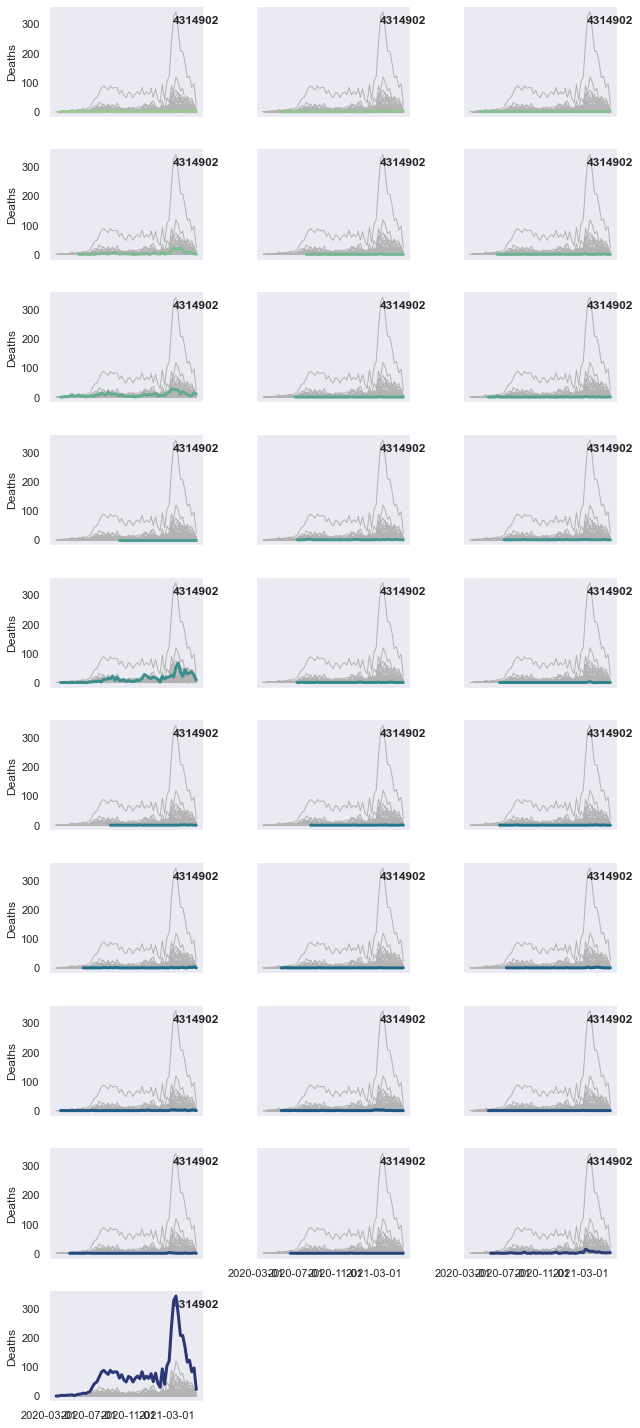

In [93]:
sns.set_theme(style="dark")

# Plot each year's time series in its own facet
g = sns.relplot(
    data=cases_rs_clip2,
    x="epi_week_date", y=var, col="ibge_code", hue="ibge_code",
    kind="line", palette="crest", linewidth=3, zorder=5,
    col_wrap=3, height=2, aspect=1.5, legend=False,
)
for city, ax in g.axes_dict.items():

    # Add the title as an annotation within the plot
    ax.text(.8, .85, year, transform=ax.transAxes, fontweight="bold")

    # Plot every city's time series in the background
    sns.lineplot(
        data=cases_rs_plot, x="epi_week_date", y=var, units="ibge_code",
        estimator=None, color=".7", linewidth=1, ax=ax,
    )
# Reduce the frequency of the x axis ticks
ax.set_xticks(ax.get_xticks()[::2])

# Tweak the supporting aspects of the plot
g.set_titles("")
g.set_axis_labels("", "Deaths")
g.tight_layout()

In [ ]:
cities_label = ibge_codes[ibge_codes.ibge_code == cities_list[i]].mun_name


In [ ]:
def plot_kmf_alt(dataframe,cities):
    kmf = KaplanMeierFitter() 
    df = dataframe
    #list currently takes a max of 5 cities because of the ax elements in the plot at the end
    cities_list = cities

    T = df['week']     ## time to event
    E = df['event']      ## event occurred or censored


    #creating a the cohorts. this takes a list of index (named) keys
    groups = df.loc[cities_list]
    #create an empty series object to receive the dataframe for each city below
    ix = pd.Series([])
    for i in range(len(cities_list)):
        #create a temporary dataframe, holding the events for each city
        ix[i] = groups.loc[cities_list[i]].index
        cities_label = cities_list[i]
        cities_label = ibge_codes[ibge_codes.ibge_code == cities_list[i]].mun_name
        #passing on the dataframe's time and event columns to the Kaplan-Meier function, and the index keys as labels (we can search the IBGE database for its name later)
        kmf.fit(T[ix[i]], E[ix[i]], label=cities_label)    ## fit the cohort 1 data
        figsize(14,7)
        if i == 0:
            ax = kmf.plot()
        elif i > 0:
            ax1 = kmf.plot(ax=ax)
    plt.show()
    return kmf